#インポート

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.ticker as ticker
import torchvision
import math

#シード固定

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

#デバイス・データセット・モデル定義

In [3]:
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

class CNN_Model(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = torch.nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = torch.nn.GroupNorm(8, 32)
        self.act1 = torch.nn.ReLU()
        self.pool1 = torch.nn.MaxPool2d(2)

        self.conv2 = torch.nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = torch.nn.GroupNorm(8, 64) 
        self.act2 = torch.nn.ReLU()
        self.pool2 = torch.nn.MaxPool2d(2)

        self.conv3 = torch.nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = torch.nn.GroupNorm(8, 128) 
        self.act3 = torch.nn.ReLU()
        self.pool3 = torch.nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = torch.nn.Linear(128, 100)
        self.act4 = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(100, 10)

    def forward(self, x):
        y = self.act1(self.bn1(self.conv1(x)))
        y = self.pool1(y)

        y = self.act2(self.bn2(self.conv2(y)))
        y = self.pool2(y)

        y = self.act3(self.bn3(self.conv3(y)))
        y = self.pool3(y)

        y = torch.flatten(y, 1)
        y = self.act4(self.fc1(y))
        y = self.fc2(y)
        return y     

#学習率・エポック数・バッチサイズ指定、データローダー作る

In [4]:
set_seed(42)
BATCH_SIZE = 512
train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True, num_workers = 0)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE, shuffle = False, num_workers = 0)

LEARNING_RATE = 0.001
EPOCHS = 500

#学習ループ

##No Full Grad SVRG

In [5]:
set_seed(42)
class NFG_SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)

    def init_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                if "a" not in state:
                    state["a"] = torch.zeros_like(p)
                    state["prev_a"] = torch.zeros_like(p) # prev_aを'a'のクローンとして初期化

                state["prev_a"].copy_(state["a"])
                state["a"].zero_()
                state['prev_p'] = torch.clone(p).detach() # prev_pの初期値はパラメータ
                state["t"] = 0
    
    def calc_full_grads(self, model, dataloader, loss_func):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        total_data = 0

        # full_grad，prev_pを初期化
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]
                state["full_grad"] = torch.zeros_like(p)

        model.train()
        for X, T in dataloader:
            X, T = X.to(device), T.to(device)

            model.zero_grad()
            Y = model(X)
            # 平均の誤差にデータ数を掛け総和に変換
            loss = loss_func(Y, T) * len(X)
            loss.backward()

            total_data += len(X)
            for group in self.param_groups:
                for p in group['params']:
                    if p.grad is None:
                        continue

                    grad = p.grad.detach()
                    state = self.state[p]
                    state["full_grad"].add_(grad)

        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["full_grad"].div_(total_data)

    def culc_prev_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["current_p"] = torch.clone(p) # 現在のパラメータをcurrent_pに保持
                    p.copy_(state["prev_p"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        # current_pに切り替え，prev_gradの保持
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    p.copy_(state["current_p"]) # パラメータをcurrent_pに変換
                    state["prev_grad"] = torch.clone(p.grad.detach())

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]

                # 補正勾配
                a = state['a']
                prev_a = state["prev_a"]
                prev_grad = state["prev_grad"]
                t = state["t"]

                # 平均勾配を更新
                a.mul_(t / (t+1)).add_(grad, alpha = 1 / (t+1))

                # 補正勾配を更新
                v = grad - prev_grad + prev_a

                # パラメータを更新
                p.sub_(v, alpha = lr)
                state["t"] += 1

        return loss

In [6]:
set_seed(42)
model = CNN_Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = NFG_SVRG(model.parameters(), lr = LEARNING_RATE)

NFG_SVRG_train_loss_history = []
NFG_SVRG_test_loss_history = []
NFG_SVRG_train_acc_history = []
NFG_SVRG_test_acc_history = []
NFG_SVRG_x = []
fg_count = 0
NFG_SVRG_norm_history = []

for epoch in range(EPOCHS):
    print(f"epoch: {epoch + 1}")
    model.train()
    train_loss, correct, total = 0, 0, 0

    optimizer.init_epoch()
    optimizer.calc_full_grads(model, train_loader, criterion)

    pb = tqdm(train_loader)
    for X, T in pb:
        X, T = X.to(device), T.to(device)

        optimizer.culc_prev_grads(model, X, T, criterion)

        optimizer.zero_grad()
        Y = model(X)
        loss = criterion(Y, T)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred = Y.argmax(dim=1)
        correct += (pred == T).sum().item()
        total += T.size(0)

        pb.set_postfix({"loss": loss.item(), "acc": correct / total})

# --- ここから追加: 平均勾配 a とフル勾配 full_grad の差の全体ノルムを計算 ---
    diff_norm_sq_sum = 0.0
    for group in optimizer.param_groups:
        for p in group['params']:
            state = optimizer.state[p]
            if "a" in state and "full_grad" in state:
                # 平均勾配 a と フル勾配 full_grad の差を計算
                diff = state["a"] - state["full_grad"]
                # 差の2乗和を累積
                diff_norm_sq_sum += torch.sum(diff ** 2).item()
    
    # 全体の2乗和の平方根をとって L2 ノルムとする
    epoch_diff_norm = math.sqrt(diff_norm_sq_sum)
    NFG_SVRG_norm_history.append(epoch_diff_norm)
    # --- ここまで追加 ---

    fg_count += 2
    train_loss /= len(train_loader)
    train_acc = correct / total

    NFG_SVRG_x.append(fg_count)
    NFG_SVRG_train_loss_history.append(train_loss)
    NFG_SVRG_train_acc_history.append(train_acc)


    model.eval()
    test_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        pb = tqdm(test_loader)
        for X, T in pb:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = criterion(Y, T)

            test_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

    test_loss /= len(test_loader)
    test_acc = correct / total

    NFG_SVRG_test_loss_history.append(test_loss)
    NFG_SVRG_test_acc_history.append(test_acc)

    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

epoch: 1


100%|██████████| 20/20 [00:00<00:00, 29.43it/s, loss=2.33, acc=0.0986]


Train Loss: 2.3202, Acc: 0.0986 | Test Loss: 2.3204, Acc: 0.0986
epoch: 2


100%|██████████| 20/20 [00:00<00:00, 28.14it/s, loss=2.31, acc=0.0999]


Train Loss: 2.3129, Acc: 0.0996 | Test Loss: 2.3073, Acc: 0.0999
epoch: 3


...

Train Loss: 1.1078, Acc: 0.6019 | Test Loss: 1.1532, Acc: 0.5835
epoch: 426


100%|██████████| 20/20 [00:00<00:00, 27.19it/s, loss=1.26, acc=0.571]


Train Loss: 1.1239, Acc: 0.5964 | Test Loss: 1.1892, Acc: 0.5709
epoch: 427


  2%|▏         | 2/98 [00:00<00:09, 10.13it/s, loss=1.17, acc=0.576]


KeyboardInterrupt: 

##Primal No Full Grad SVRG

In [8]:
set_seed(42)
class Primal_NFG_SVRG(optim.Optimizer):
    def __init__(self, params, lr = LEARNING_RATE):
        defaults = dict(lr = lr,)
        super().__init__(params, defaults)

    def init_epoch(self):
        for group in self.param_groups:
            for p in group['params']:
                state = self.state[p]

                if "a" not in state:
                    state["a"] = torch.zeros_like(p)
                    state["prev_a"] = torch.zeros_like(p)
                    state["z"] = torch.clone(p.detach())
                    state["prev_z"] = torch.clone(p.detach())

                state["prev_a"].copy_(state["a"])
                state["a"].zero_()
                state['prev_z'].copy_(state["z"])
                state["z"].zero_()
                state["t"] = 0

    def culc_prev_grads(self, model, X, T, loss_func):
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["current_p"] = torch.clone(p) # 現在のパラメータをcurrent_pに保持
                    p.copy_(state["prev_z"])

        model.zero_grad()
        Y = model(X)
        loss = loss_func(Y, T)
        loss.backward()

        # current_pに切り替え，prev_gradの保持
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    p.copy_(state["current_p"]) # パラメータをcurrent_pに変換
                    state["prev_grad"] = torch.clone(p.grad.detach())
    
    def calc_full_grads(self, model, dataloader, loss_func):
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        total_data = 0

        # 【追加】勾配計算の前に、現在のパラメータを退避し、平均パラメータ(prev_z)をモデルにセット
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["full_grad"] = torch.zeros_like(p)
                    # 現在のパラメータを保持し、モデルの重みを prev_z に差し替える
                    if "prev_z" in state:
                        state["current_p_temp"] = torch.clone(p.detach())
                        p.copy_(state["prev_z"])

        model.train()
        for X, T in dataloader:
            X, T = X.to(device), T.to(device)

            model.zero_grad()
            Y = model(X)
            # 平均の誤差にデータ数を掛け総和に変換 (loss_funcがmeanを返す前提であればこれで正解です)
            loss = loss_func(Y, T) * len(X)
            loss.backward()

            total_data += len(X)
            for group in self.param_groups:
                for p in group['params']:
                    if p.grad is None:
                        continue

                    grad = p.grad.detach()
                    state = self.state[p]
                    state["full_grad"].add_(grad)

        # 【追加】計算完了後、フル勾配をデータ数で割り、モデルのパラメータを元の状態に復元
        with torch.no_grad():
            for group in self.param_groups:
                for p in group['params']:
                    state = self.state[p]
                    state["full_grad"].div_(total_data)
                    
                    # 退避しておいた元のパラメータを復元する
                    if "current_p_temp" in state:
                        p.copy_(state["current_p_temp"])
                        del state["current_p_temp"] # 不要になったので削除

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        for group in self.param_groups:
            lr = group['lr']
            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad.detach()
                state = self.state[p]

                a = state['a']
                prev_a = state["prev_a"]
                prev_grad = state["prev_grad"]
                z = state["z"]
                t = state["t"]

                # 平均勾配を更新
                a.mul_(t / (t+1)).add_(grad, alpha = 1 / (t+1))
                # 補正勾配を更新
                v = grad - prev_grad + prev_a
                # パラメータを更新
                p.sub_(v, alpha = lr)
                # 平均パラメーターを更新
                z.mul_(t / (t+1)).add_(p, alpha = 1 / (t+1))
                state["t"] += 1

        return loss

In [9]:
set_seed(42)
model = CNN_Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = Primal_NFG_SVRG(model.parameters(), lr = LEARNING_RATE)

Primal_NFG_SVRG_train_loss_history = []
Primal_NFG_SVRG_test_loss_history = []
Primal_NFG_SVRG_train_acc_history = []
Primal_NFG_SVRG_test_acc_history = []
Primal_NFG_SVRG_x = []
fg_count = 0
ASAI_SVRG_norm_history = []

for epoch in range(EPOCHS):
    print(f"epoch: {epoch + 1}")
    model.train()
    train_loss, correct, total = 0, 0, 0

    optimizer.init_epoch()
    optimizer.calc_full_grads(model, train_loader, criterion)

    pb = tqdm(train_loader)
    for X, T in pb:
        X, T = X.to(device), T.to(device)

        optimizer.culc_prev_grads(model, X, T, criterion)

        optimizer.zero_grad()
        Y = model(X)
        loss = criterion(Y, T)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pred = Y.argmax(dim=1)
        correct += (pred == T).sum().item()
        total += T.size(0)

        pb.set_postfix({"loss": loss.item(), "acc": correct / total})

# --- ここから追加: 平均勾配 a とフル勾配 full_grad の差の全体ノルムを計算 ---
    diff_norm_sq_sum = 0.0
    for group in optimizer.param_groups:
        for p in group['params']:
            state = optimizer.state[p]
            if "a" in state and "full_grad" in state:
                # 平均勾配 a と フル勾配 full_grad の差を計算
                diff = state["a"] - state["full_grad"]
                # 差の2乗和を累積
                diff_norm_sq_sum += torch.sum(diff ** 2).item()
    
    # 全体の2乗和の平方根をとって L2 ノルムとする
    epoch_diff_norm = math.sqrt(diff_norm_sq_sum)
    ASAI_SVRG_norm_history.append(epoch_diff_norm)
    # --- ここまで追加 ---

    fg_count += 2
    train_loss /= len(train_loader)
    train_acc = correct / total

    Primal_NFG_SVRG_x.append(fg_count)
    Primal_NFG_SVRG_train_loss_history.append(train_loss)
    Primal_NFG_SVRG_train_acc_history.append(train_acc)


    model.eval()
    test_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        pb = tqdm(test_loader)

        backup = []
        with torch.no_grad():
            for group in optimizer.param_groups:
                for p in group['params']:
                    state = optimizer.state[p]
                    backup.append(p.clone())
                    p.copy_(state["z"])

        for X, T in pb:
            X, T = X.to(device), T.to(device)

            Y = model(X)
            loss = criterion(Y, T)

            test_loss += loss.item()

            pred = Y.argmax(dim=1)
            correct += (pred == T).sum().item()
            total += T.size(0)

            pb.set_postfix({"loss": loss.item(), "acc": correct / total})

        with torch.no_grad():
            i = 0
            for group in optimizer.param_groups:
                for p in group['params']:
                    p.copy_(backup[i])
                    i += 1

    test_loss /= len(test_loader)
    test_acc = correct / total

    Primal_NFG_SVRG_test_loss_history.append(test_loss)
    Primal_NFG_SVRG_test_acc_history.append(test_acc)

    print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}", "|", f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.4f}")

epoch: 1


100%|██████████| 20/20 [00:00<00:00, 23.45it/s, loss=2.33, acc=0.0986]


Train Loss: 2.3202, Acc: 0.0986 | Test Loss: 2.3204, Acc: 0.0986
epoch: 2


100%|██████████| 20/20 [00:00<00:00, 26.94it/s, loss=2.32, acc=0.0997]


Train Loss: 2.3129, Acc: 0.0996 | Test Loss: 2.3128, Acc: 0.0997
epoch: 3


...

Train Loss: 0.9887, Acc: 0.6464 | Test Loss: 1.0185, Acc: 0.6367
epoch: 499


100%|██████████| 20/20 [00:00<00:00, 27.36it/s, loss=1.08, acc=0.636] 


Train Loss: 0.9942, Acc: 0.6439 | Test Loss: 1.0181, Acc: 0.6357
epoch: 500


100%|██████████| 20/20 [00:00<00:00, 26.98it/s, loss=1.08, acc=0.637] 

Train Loss: 0.9828, Acc: 0.6490 | Test Loss: 1.0175, Acc: 0.6367


#結果

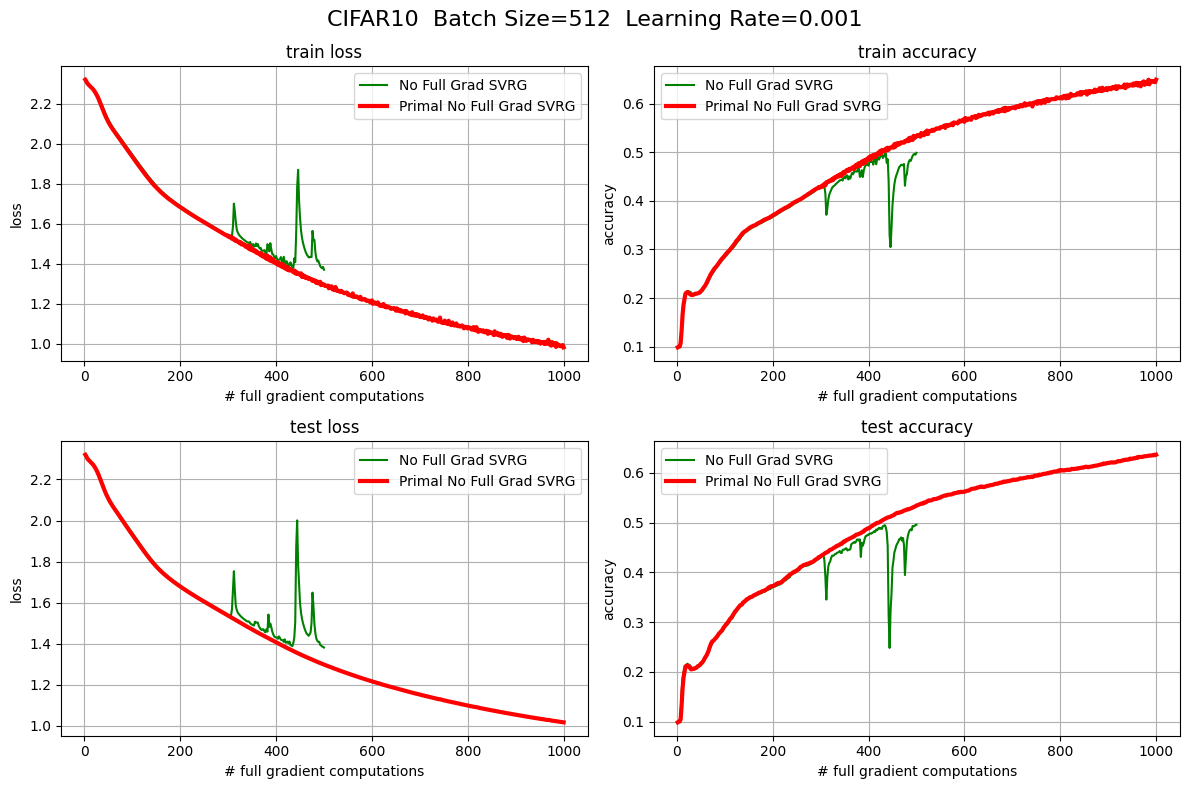

In [ ]:
fig = plt.figure(figsize = (12, 8))
fig.suptitle(f"CIFAR10  Batch Size={BATCH_SIZE}  Learning Rate={LEARNING_RATE}",fontsize=16)
ax = fig.add_subplot(2, 2, 1)
ax.plot(NFG_SVRG_x, NFG_SVRG_train_loss_history, label = "No Full Grad SVRG", c='green')
ax.plot(Primal_NFG_SVRG_x, Primal_NFG_SVRG_train_loss_history, label = "Primal No Full Grad SVRG", linewidth = 3, c='red')
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("train loss")
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 2)
ax.plot(NFG_SVRG_x, NFG_SVRG_train_acc_history, label = "No Full Grad SVRG", c='green')
ax.plot(Primal_NFG_SVRG_x, Primal_NFG_SVRG_train_acc_history, label = "Primal No Full Grad SVRG", linewidth = 3, c='red')
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("accuracy")
ax.set_title("train accuracy")
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 3)
ax.plot(NFG_SVRG_x, NFG_SVRG_test_loss_history, label = "No Full Grad SVRG", c='green')
ax.plot(Primal_NFG_SVRG_x, Primal_NFG_SVRG_test_loss_history, label = "Primal No Full Grad SVRG", linewidth = 3, c='red')
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("loss")
ax.set_title("test loss")
ax.grid()
ax.legend()

ax = fig.add_subplot(2, 2, 4)
ax.plot(NFG_SVRG_x, NFG_SVRG_test_acc_history, label = "No Full Grad SVRG", c='green')
ax.plot(Primal_NFG_SVRG_x, Primal_NFG_SVRG_test_acc_history, label = "Primal No Full Grad SVRG", linewidth = 3, c='red')
ax.set_xlabel("# full gradient computations")
ax.set_ylabel("accuracy")
ax.set_title("test accuracy")
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()

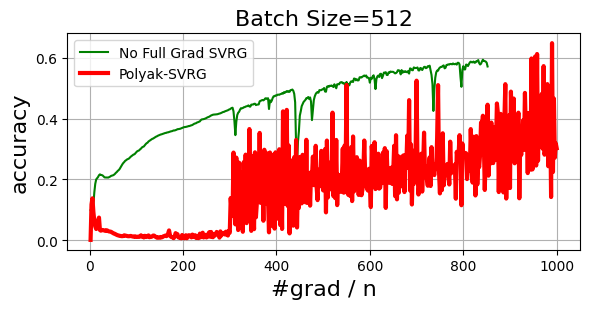

In [13]:
fig = plt.figure(figsize = (6, 3.2))
ax = fig.add_subplot()
ax.plot(NFG_SVRG_x, NFG_SVRG_test_acc_history, label = "No Full Grad SVRG", c='green')
ax.plot(Primal_NFG_SVRG_x, ASAI_SVRG_norm_history, label = "Polyak-SVRG", linewidth = 3, c='red')
ax.set_xlabel("#grad / n", fontsize=16)
ax.set_ylabel("accuracy", fontsize=16)
ax.set_title(f"Batch Size={BATCH_SIZE}" ,fontsize=16)
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()

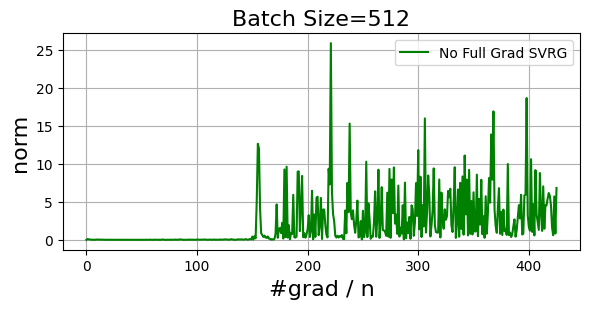

In [14]:
fig = plt.figure(figsize = (6, 3.2))
ax = fig.add_subplot()
ax.plot(NFG_SVRG_norm_history, label = "No Full Grad SVRG", c='green')
ax.set_xlabel("#grad / n", fontsize=16)
ax.set_ylabel("norm", fontsize=16)
ax.set_title(f"Batch Size={BATCH_SIZE}" ,fontsize=16)
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()

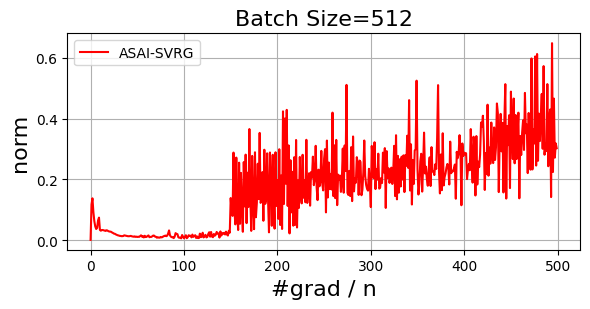

In [10]:
fig = plt.figure(figsize = (6, 3.2))
ax = fig.add_subplot()
ax.plot(ASAI_SVRG_norm_history, label = "ASAI-SVRG", c='red')
ax.set_xlabel("#grad / n", fontsize=16)
ax.set_ylabel("norm", fontsize=16)
ax.set_title(f"Batch Size={BATCH_SIZE}" ,fontsize=16)
ax.grid()
ax.legend()

plt.tight_layout()
plt.show()